In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import os
import joblib
import torch
import torch.nn as nn
import torchvision
import deepRD
import deepRD.tools.trajectoryTools as trajectoryTools
import deepRD.noiseSampler.newCvae as newCvae
from deepRD.diffusionIntegrators import langevinNoiseSampler
#from deepRD.diffusionIntegrators import langevinInteractionSampler
from deepRD.potentials import bistable
from deepRD.noiseSampler import cvaeSampler, newCvae
#from deepRD.noiseSampler import binnedData
import deepRD.tools.trajectoryTools as trajectoryTools
import deepRD.tools.analysisTools as analysisTools

In [15]:
# Simulation parameters
#localDataDirectory = '../../data/stochasticClosure/'
localDataDirectory = os.environ['DATA'] + 'stochasticClosure/'
bsize = 5 #5 #8 #10
systemType='bistable'
outputAux = True #False

conditionedOn = 'piririm' # Available conditionings: qi, pi, ri, qiri, piri, qiririm, piririm

# Loading parameter dictionary
parentDirectory = os.environ['DATA'] + 'stochasticClosure/bistable/boxsize' + str(bsize)+ '/benchmark/'
parameters = analysisTools.readParameters(parentDirectory + "parameters")
#print(parameters)

# Extract basic parameters
dt = parameters['dt']
Gamma = parameters['Gamma']
mass =  parameters['mass']
KbT = parameters['KbT']
boxsize = parameters['boxsize']
boundaryType = parameters['boundaryType']

# Parameters for external potential (will only acts on distinguished particles (type 1)
minimaDist = 1.5
kconstants = np.array([1.0, 1.0, 1.0])
scalefactor = 1

# Integrator parameters
#integratorStride = 1 #50
#numSimulations = 100
#tfinal = 10000
#equilibrationSteps = 10000

# dev settings for testing.
integratorStride = 1 #50
nTrajs = 10
tfinal = 500
equilibrationSteps = 2000

In [16]:
def runTestSims(nSampler, simnumber=np.random.randint(50)):
    
    nSampler.eval()

    # Define particle list
    seed = int(simnumber)
    random.seed(seed)
    position = [0, 0, 0]
    velocity = [0, 0, 0]
    particle = deepRD.particle(position, velocity=velocity, mass=mass)
    particleList = deepRD.particleList([particle])

    # Define external potential
    bistablePotential = bistable(minimaDist, kconstants, scalefactor)

    diffIntegrator = langevinNoiseSampler(dt, integratorStride, tfinal, Gamma, nSampler, KbT,
                                          boxsize, boundaryType, equilibrationSteps, conditionedOn)

    diffIntegrator.setExternalPotential(bistablePotential)

    # Integrate dynamics
    t, X, V, Raux = diffIntegrator.propagate(particleList, outputAux = outputAux)
    
    traj = trajectoryTools.convert2trajectory(t, [X, V, Raux])
    print(f'Simulation {simnumber} done. \r')
    
    return traj

In [17]:
valModel = newCvae.CVAE(cond_type=conditionedOn)

scalers = joblib.load("normalizers/normalizers_"+conditionedOn+".pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load("checkpoints/cvae_checkpoint_"+conditionedOn+".pt", map_location="cpu", weights_only=True)
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [18]:
trajs = [runTestSims(valModel, simnumber=i+1) for i in range(nTrajs)]

Simulation 1 done. 
Simulation 2 done. 
Simulation 3 done. 
Simulation 4 done. 
Simulation 5 done. 
Simulation 6 done. 
Simulation 7 done. 
Simulation 8 done. 
Simulation 9 done. 
Simulation 10 done. 


In [19]:
dataset = torch.tensor(np.array(trajs))
dataset.shape

torch.Size([10, 10000, 10])

In [20]:
# Loading Benchmark data for comparison
nTimestepsBench = 10000

benchDataset = torch.empty((nTrajs, nTimestepsBench, 10))

fileIDS = np.sort(np.random.choice(2500, nTrajs, replace=False))

benchFileDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/bistable/boxsize5/benchmark/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(benchFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue

    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    benchDataset[j] = ds

In [21]:
timesteps = dataset[:, :, 0]
qT = dataset[:, :, 1:4]
rAuxT = dataset[:, :, -3:]
rNxtT = torch.roll(rAuxT, -1, 2)
vT = dataset[:, :, 4:7]

b_timesteps = benchDataset[:, :, 0]
b_qT = benchDataset[:, :, 1:4]
b_rAuxT = benchDataset[:, :, -3:]
b_rNxtT = torch.roll(b_rAuxT, -1, 2)
b_vT = benchDataset[:, :, 4:7]

rAuxT.shape, b_rAuxT.shape

(torch.Size([10, 10000, 3]), torch.Size([10, 10000, 3]))

In [22]:
print('Velocity')

print(f'Mean Bench: \t', torch.mean(b_vT, dim=(0,1)))
print('Mean Reduced:\t', torch.mean(vT, dim=(0,1)))

print('\nStd Bench: \t', torch.std(b_vT, dim=(0,1)))
print('Std Reduced:\t', torch.std(vT, dim=(0,1)))

    
print('\n Auxiliary Var')
print('Mean Bench: \t', torch.mean(b_rAuxT, dim=(0,1)))
print('Mean Reduced:\t', torch.mean(rAuxT, dim=(0,1)))


print('\nStd Bench: \t', torch.std(b_rAuxT, dim=(0,1)))
print('Std Reduced:\t', torch.std(rAuxT, dim=(0,1)))

Velocity
Mean Bench: 	 tensor([-0.0024,  0.0001,  0.0020])
Mean Reduced:	 tensor([ 0.0021,  0.0016, -0.0022], dtype=torch.float64)

Std Bench: 	 tensor([0.1433, 0.1404, 0.1447])
Std Reduced:	 tensor([0.1409, 0.1442, 0.1446], dtype=torch.float64)

 Auxiliary Var
Mean Bench: 	 tensor([ 5.0514e-05,  6.7271e-05, -6.3409e-06])
Mean Reduced:	 tensor([-1.7968e-04,  2.3943e-04,  2.1627e-05], dtype=torch.float64)

Std Bench: 	 tensor([0.0162, 0.0161, 0.0164])
Std Reduced:	 tensor([0.0158, 0.0158, 0.0161], dtype=torch.float64)


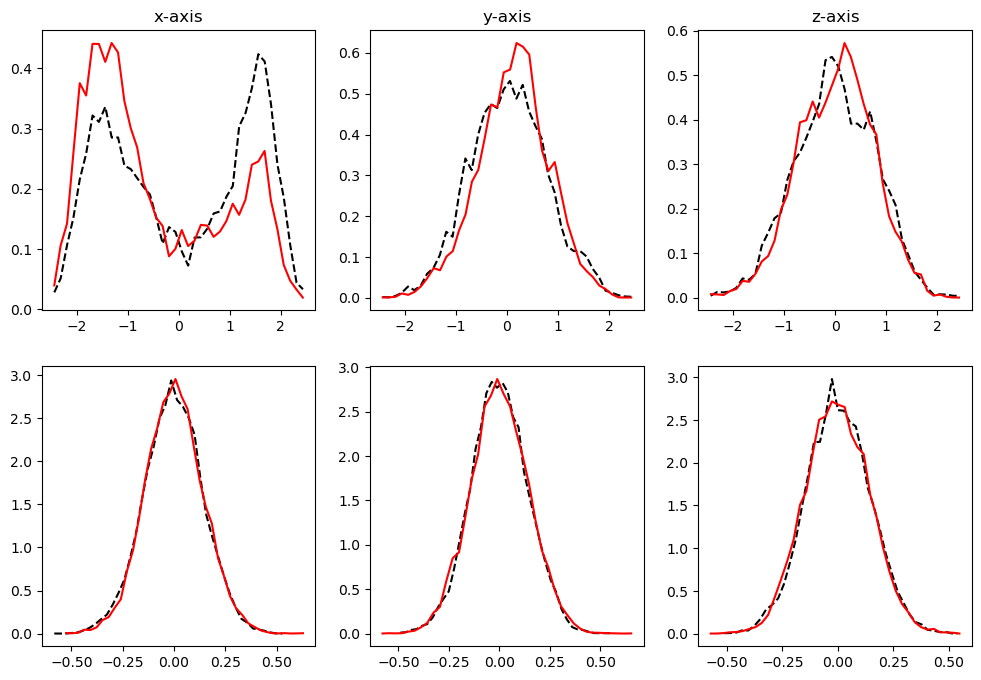

In [23]:
numbins = 40
fig, axes = plt.subplots(2, 3, figsize=(12,8))
dim_labels = ['x','y','z']

for i in range(axes.shape[1]):
    
    ax1, ax2 = axes[:, i]
    
    # Benchmark
    pos1, binEdges1 = np.histogram(b_qT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos1 = 0.5 * (binEdges1[1:] + binEdges1[:-1])
    ax1.plot(binsPos1, pos1,'k--')
    
    pos1, binEdges1 = np.histogram(b_vT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos1 = 0.5 * (binEdges1[1:] + binEdges1[:-1])
    ax2.plot(binsPos1, pos1,'k--')
    
    # Reduced model 1
    pos2, binEdges2 = np.histogram(qT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
    ax1.plot(binsPos2, pos2, 'r-')
    
    pos2, binEdges2 = np.histogram(vT[:, :, i].flatten(), bins=numbins, density=True);
    binsPos2 = 0.5 * (binEdges2[1:] + binEdges2[:-1])
    ax2.plot(binsPos2, pos2, 'r-')
    
    ax1.set_title(f'{dim_labels[i]}-axis')

In [24]:
#Calculating the Mean Squared Displacement of the particle.
b_rT = torch.norm(b_qT, dim=-1)
b_diffsq = torch.diff(b_rT, dim=-1)**2
b_MSD = torch.mean(b_diffsq)

rT = torch.norm(qT, dim=-1)
diffsq = torch.diff(rT, dim=-1)**2
MSD = torch.mean(diffsq)

print('Mean Square Displacement:')
print('Benchmark:', float(b_MSD))
print('Model 1:', float(MSD))

Mean Square Displacement:
Benchmark: 5.10185091116e-05
Model 1: 5.0055500488545025e-05


In [25]:
lagtimesteps = 2000

def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

In [26]:
# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros((2, 2, lagtimesteps))
    
for trajInd in range(nTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += np.sum([correlation_fft(b_qT[trajInd, :, i], b_qT[trajInd, :, i], lagtimesteps) for i in range(b_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[0, 1] += np.sum([correlation_fft(b_vT[trajInd, :, i], b_vT[trajInd, :, i], lagtimesteps) for i in range(b_vT.shape[2])], axis=0)
    
    #print('Reduced')
    ACF_FFT[1, 0] += np.sum([correlation_fft(qT[trajInd, :, i], qT[trajInd, :, i], lagtimesteps) for i in range(qT.shape[2])], axis=0)
    ACF_FFT[1, 1] += np.sum([correlation_fft(vT[trajInd, :, i], vT[trajInd, :, i], lagtimesteps) for i in range(vT.shape[2])], axis=0)
    
ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]

ACF_FFT[1, 0] /= ACF_FFT[1, 0, 0]
ACF_FFT[1, 1] /= ACF_FFT[1, 1, 0]

<function matplotlib.pyplot.show(close=None, block=None)>

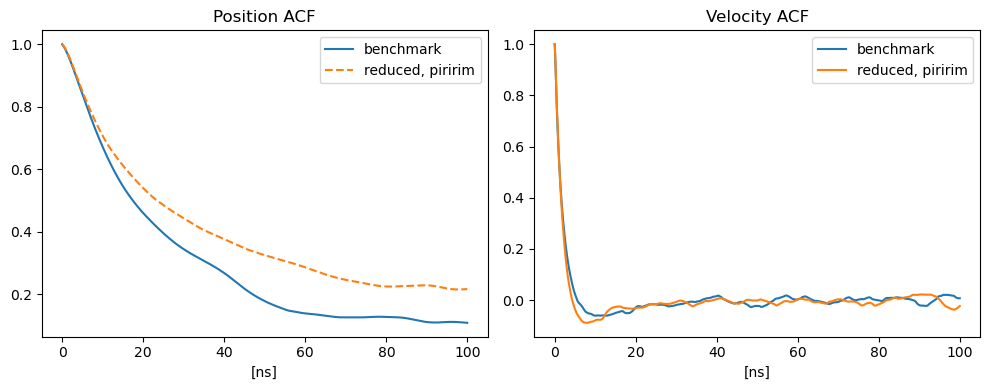

In [27]:
# Plotting comparison for ACFs

# timestep - 0.05 nanoseconds
# 2000 timesteps - 100 ns

time = np.arange(lagtimesteps)*0.05
fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].plot(time, ACF_FFT[0, 0], label='benchmark')
axes[0].plot(time, ACF_FFT[1, 0], '--', label=f'reduced, {conditionedOn}')
axes[0].set_title('Position ACF')
axes[0].set_xlabel('[ns]')
axes[0].legend()

axes[1].plot(time, ACF_FFT[0, 1], label='benchmark')
axes[1].plot(time, ACF_FFT[1, 1], label=f'reduced, {conditionedOn}')
axes[1].set_title('Velocity ACF')
axes[1].set_xlabel('[ns]')
axes[1].legend()

plt.tight_layout()
plt.show

In [23]:
def free_bits_lambda(epoch, warm=30, decay_to=0.05, start=0.5, total=80):
    if epoch <= warm:
        return start - (start-0.2) * (epoch/warm)
    # decay further to decay_to
    t = min(1.0, (epoch - warm) / (total - warm))
    return 0.2 - (0.2 - decay_to) * t

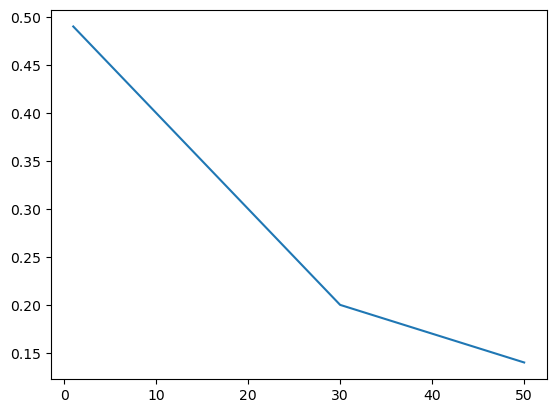

In [24]:
x = np.arange(1, 51)
plt.plot(x, [free_bits_lambda(y) for y in x])